In [67]:
import numpy as np
import torch
import sys
from collections import defaultdict
from sklearn.model_selection import KFold
import os
import multiprocessing
import argparse
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, classification_report, confusion_matrix
from tqdm import tqdm
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
os.chdir("/root/sunxh/WaveCrossMamba") 
print(os.getcwd()) 
from model.model import WaveCrossMamba,AnomalyDetectionModel
from utils.dataloader import UnlabeledDataset,SupervisedDataset,load_data_supervised,load_data_unsupervised,get_negative_samples,SubAnomaly
from train_test.anomaly_detection import test_model
import os
from train_test.anomaly_detection import test_model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from utils.Dynamic_weight_sampler import make_weights_for_balanced_classes,CustomWeightedRandomSampler
import torch.multiprocessing as mp
torch.cuda.empty_cache() 
print("开始测试过程")

/root/sunxh/WaveCrossMamba
开始测试过程


In [2]:
import torch
import numpy as np

def test_model(pretrain_model, model, test_loader, device):
    model.to(device)
    pretrain_model.to(device)
    all_labels = [] 
    all_embeddings = [] 
    model.eval()
    pretrain_model.eval()
    with torch.no_grad():
        for batch_idx, (data, rog, targets) in enumerate(test_loader):
            x, kmer, mean, std, intense, dwell, base_quality = data
 
            x = x.to(device)
            kmer = kmer.to(device)
            mean = mean.to(device)
            std = std.to(device)
            intense = intense.to(device)
            dwell = dwell.to(device)
            base_quality = base_quality.to(device)
            targets = targets.to(device)
            
 
            if targets.dtype != torch.long:
                targets = targets.long()
            
 
            x = x.unsqueeze(2)
            
 
            logits, ff = pretrain_model(x, kmer, mean, std, intense, dwell, base_quality)
            
 
            all_embeddings.append(logits.cpu().numpy()) 
            all_labels.append(targets.cpu().numpy()) 
    
 
    all_embeddings = np.concatenate(all_embeddings, axis=0) 
    all_labels = np.concatenate(all_labels, axis=0) 
    
 
    return all_embeddings, all_labels


In [47]:
data_files = [
    ('/root/sunxh/WaveCrossMamba/dataset/test.ivet.m6a.tsv', 1), 
    ('/root/sunxh/WaveCrossMamba/dataset/test.ivet.unmod.a.tsv', 0) 
]
print(data_files)
print("成功")
data_length = int(200) 
(X_test, Y_test),_ = load_data_supervised(data_files, data_length, validation_split=0.0) 
test_dataset = SupervisedDataset(X_test, Y_test,augment=False, num_aug=1)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=16,
    pin_memory=True
)
print("测试数据加载完成。") 
pretrained_feature_extractor  = WaveCrossMamba(device=device,d_model=128).to(device)
fine_tune_model  = AnomalyDetectionModel(feature_dim=128, num_classes=2).to(device)
pretrained_feature_extractor.load_state_dict(torch.load(f'/root/sunxh/WaveCrossMamba/save_result/pre_ivet_m6a.pth',map_location=device))
fine_tune_model.load_state_dict(torch.load(f'/root/sunxh/WaveCrossMamba/save_result/fine_ivet_m6a.pth', map_location=device))
print("开始评估异常检测模型...")

[('/root/sunxh/WaveCrossMamba/dataset/test.ivet.m6a.tsv', 1), ('/root/sunxh/WaveCrossMamba/dataset/test.ivet.unmod.a.tsv', 0)]
成功
文件 /root/sunxh/WaveCrossMamba/dataset/test.ivet.m6a.tsv 中加载了 200 条数据
文件 /root/sunxh/WaveCrossMamba/dataset/test.ivet.unmod.a.tsv 中加载了 200 条数据
总数据量: 400
训练集大小: 400
验证集大小: 0
测试数据加载完成。
开始评估异常检测模型...


In [48]:
embeddings, labels = test_model(pretrained_feature_extractor, fine_tune_model, test_loader, device)

np.save("/root/sunxh/WaveCrossMamba/sunxh_data/m6a_embeddings.npy", embeddings) 
np.save("/root/sunxh/WaveCrossMamba/sunxh_data/m6a_labels.npy", labels) 

print("嵌入向量和标签已保存到 embeddings.npy 和 labels.npy")

嵌入向量和标签已保存到 embeddings.npy 和 labels.npy


In [49]:
import numpy as np


embeddings = np.load("/root/sunxh/WaveCrossMamba/sunxh_data/m6a_embeddings.npy")
labels = np.load("/root/sunxh/WaveCrossMamba/sunxh_data/m6a_labels.npy")


print("嵌入向量形状:", embeddings.shape)
print("标签分布:", np.unique(labels, return_counts=True))



嵌入向量形状: (400, 256)
标签分布: (array([0, 1]), array([200, 200]))


降维后的嵌入向量形状: (400, 2)


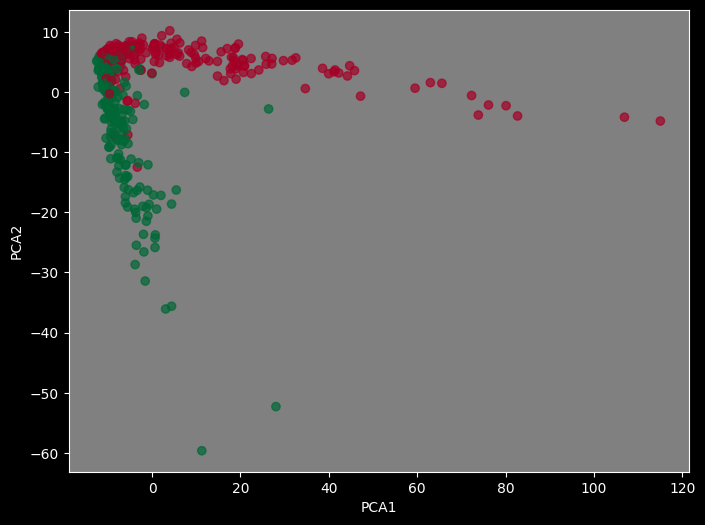

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from plotnine import *
import matplotlib.pyplot as plt
import numpy as np
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)
print("降维后的嵌入向量形状:", embeddings_pca.shape)



In [66]:
#"#F8766D" "#00BA38" "#619CFF"
black = '#222222'
gray = '#666666'
red = '#FF3333'
green = '#66CC00'
blue = '#3333FF'
purple = '#9933FF'
orange = '#FF8000'
yellow = '#FFFF33'
salmen = "#FA8072"
limegreen = '#32CD32'
deepskyblue = '#00AFEE'
c1="#F8766D"
c2="#00BA38"
c3="#619CFF"

df = pd.DataFrame(embeddings_pca, columns=['PCA1', 'PCA2'])
df['labels'] = labels


plot = (ggplot(df, aes(x='PCA1', y='PCA2', color='factor(labels)'))
        + geom_point(size=0.05,alpha=0.5)
        + scale_color_manual(
            values={0: 'red', 1: 'green'}, 
            labels={0: 'normalA', 1: 'm6A'} 
        )
        + theme(
            figure_size=[2.5,2],
            axis_text=element_text(size=8,color="black"),
            axis_title_x=element_text(size=8,color="black"),
            axis_title_y=element_text(size=8,color="black"),
            panel_background=element_rect(fill=gray,alpha=0), 
            plot_background=element_blank(), 
            panel_grid_major=element_line(size=0.3, alpha=0.3,color=black,linetype='--'),
            panel_grid_minor=element_line(size=0.3, alpha=0.3,color=black,linetype='--'),
            panel_border=element_rect(color=black, size=1),
            legend_title = element_text(size=6,alpha=0),
            legend_text = element_text(size=6),
            legend_background=element_rect(size=0.5,alpha=0),
            legend_position=(1,0.2), 
            legend_key_size=4
        )
)


plot
ggsave(plot, '/root/sunxh/WaveCrossMamba/sunxh_data/pca_m6a_visualization.pdf')


PCA 降维后的嵌入向量形状: (2000, 2)
<ggplot: (152 x 122)>
